# Bike Sharing Demand Forecasting

Bike Sharing Demand Forecasting using SARIMA / SARIMAX


Research Question:
Can historical bike usage and weather data be used to
accurately forecast short-term (hourly) bike rental demand
using time-series models?

Models used:
1. SARIMA  (univariate time-series)
2. SARIMAX (time-series with exogenous variables)

Dataset: UCI Bike Sharing Dataset (hour.csv)
Target: cnt (hourly bike rental demand)

## 1. Methodology
### 1.1 Libraries and Environment Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

### 1.2 Data Loading and Time Index Construction

SARIMA-based models require a strictly ordered time index and equally spaced observations, both of which are satisfied by hourly bike rental data.

In [2]:
# Load hourly dataset
df = pd.read_csv("data/hour.csv")

# Convert date column to datetime
df["dteday"] = pd.to_datetime(df["dteday"])

# Combine date and hour to form a proper timestamp
df["timestamp"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")

# Sort chronologically
df = df.sort_values("timestamp")

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Target variable
y = df["cnt"]

y.head()


timestamp
2011-01-01 00:00:00    16
2011-01-01 01:00:00    40
2011-01-01 02:00:00    32
2011-01-01 03:00:00    13
2011-01-01 04:00:00     1
Name: cnt, dtype: int64

### 1.3 Exploratory Time-Series Analysis

Hourly Demand Over Time

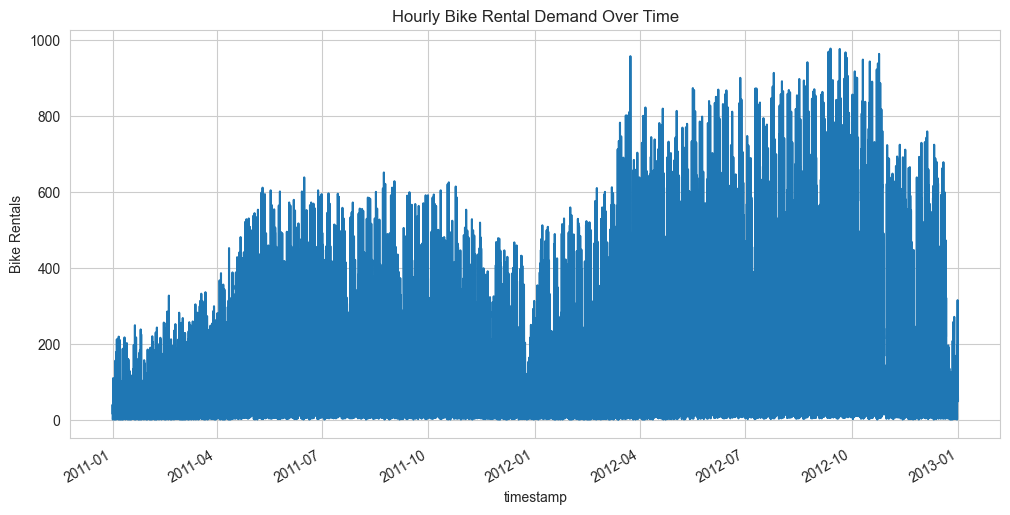

In [3]:
y.plot(title="Hourly Bike Rental Demand Over Time")
plt.ylabel("Bike Rentals")
plt.show()

The series shows:

1. Long-term upward trend

2. Strong seasonal patterns

3. Repeating daily cycles

This indicates the need for seasonal differencing.

### 1.4 Exploratory Visualizations

### Plot
Hourly Demand Over Time

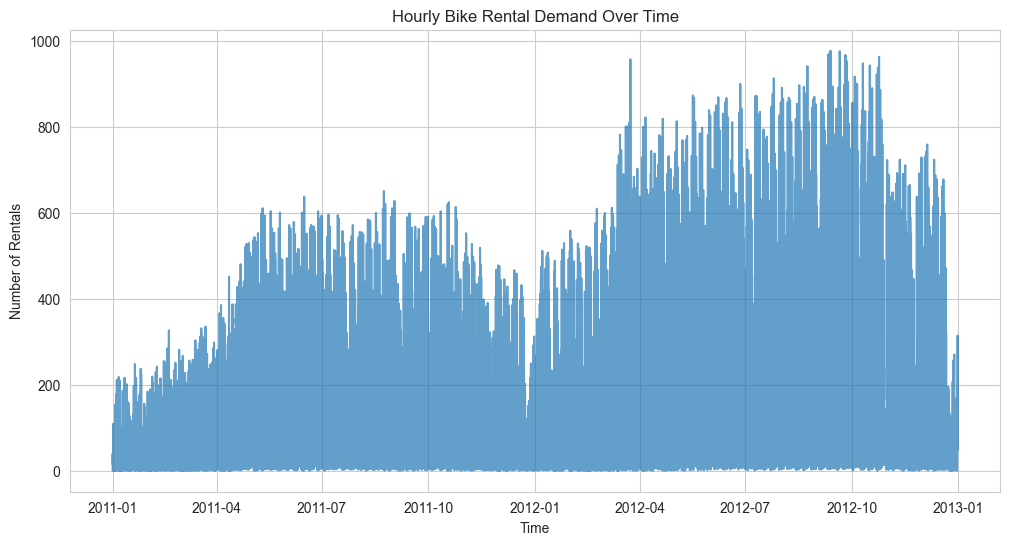

In [4]:
plt.plot(df.index, df["cnt"], alpha=0.7)
plt.title("Hourly Bike Rental Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Rentals")
plt.show()


Observation: Clear trend and seasonality are visible, confirming the need for time-series–aware modeling.

### Plot: 

Average Demand by Hour of Day

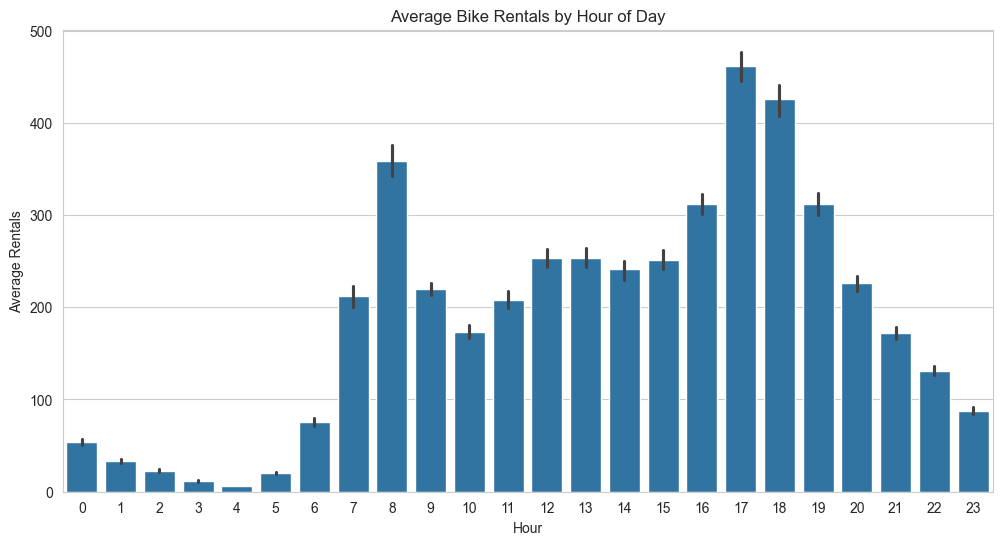

In [5]:
sns.barplot(x="hr", y="cnt", data=df, estimator=np.mean)
plt.title("Average Bike Rentals by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

Observation: Distinct morning and evening peaks align with commuter behavior.

## 1.4 Seasonality Inspection

Since the data is hourly, common seasonal cycles include:

Daily seasonality → 24 hours

Weekly seasonality → 168 hours

For simplicity and interpretability, we model daily seasonality (s = 24).

## 1.5 Train–Test Split (Time-Based)

In [6]:
# Train-test split (last 10% for testing)
split_index = int(len(y) * 0.9)

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 15641
Test size: 1738


# 2. Stationarity and Differencing

## 2.1 Differenced Series

In [7]:
# First-order differencing
y_diff = y_train.diff().dropna()

# Seasonal differencing (daily)
y_seasonal_diff = y_diff.diff(24).dropna()

# 3. ACF and PACF Analysis

## 3.1 ACF Plot

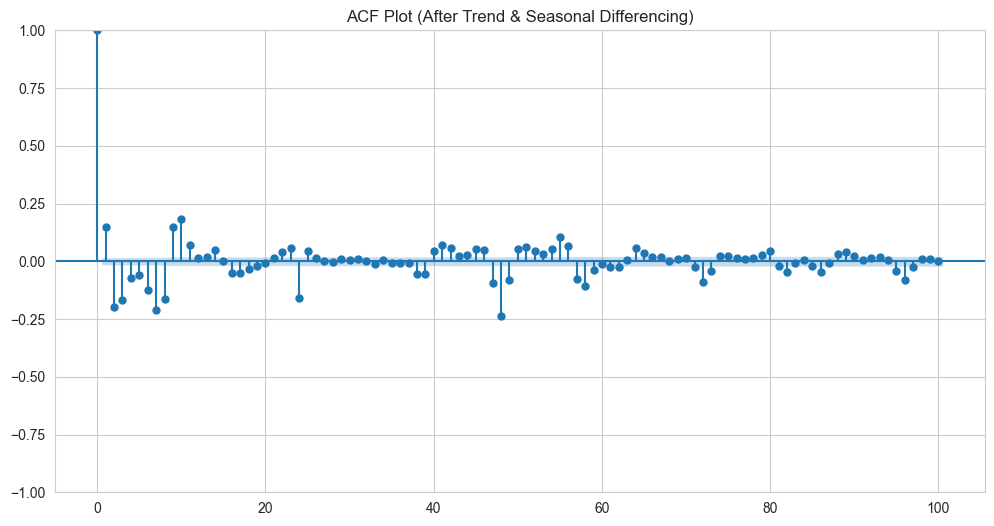

In [8]:
plot_acf(y_seasonal_diff, lags=100)
plt.title("ACF Plot (After Trend & Seasonal Differencing)")
plt.show()


Interpretation:
- Significant spikes at lag 1 suggest an MA(1) component
- Seasonal spikes at multiples of 24 indicate remaining seasonal dependence

## 3.2 PACF Plot

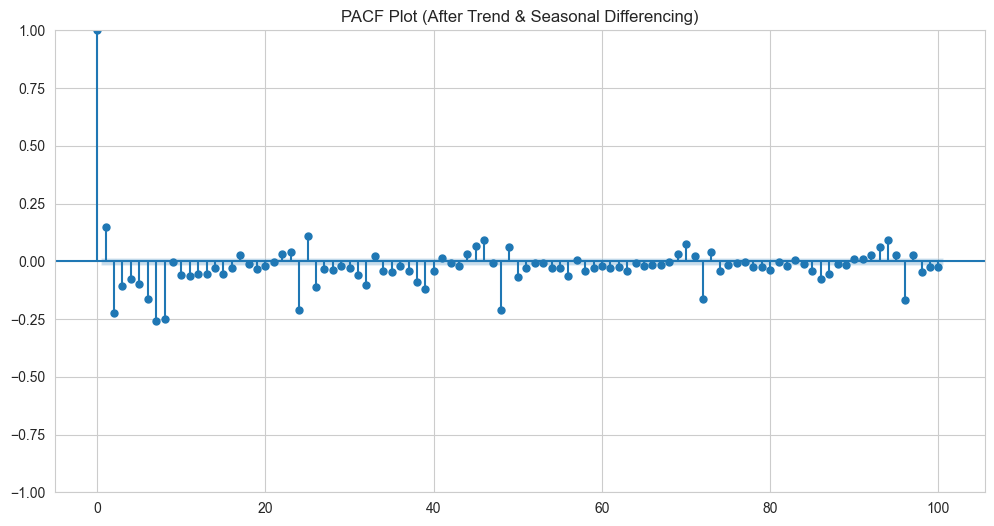

In [9]:
plot_pacf(y_seasonal_diff, lags=100, method="ywm")
plt.title("PACF Plot (After Trend & Seasonal Differencing)")
plt.show()

Interpretation:

- Significant spike at lag 1 suggests AR(1)
- Seasonal spike at lag 24 supports seasonal AR term

# 5. SARIMA Model (Univariate)

## 5.1 Model Specification

A general SARIMA model is defined as:

$$SARIMA(p,d,q)(P,D,Q)$$


Where:

$p,d,q$: non-seasonal AR, differencing, MA terms

$P,D,Q$: seasonal AR, differencing, MA terms

$s$: seasonal period (24 for hourly data)

## 5.2 Hypothesis

Based on ACF/PACF:

- Non-seasonal: (p,d,q) = (1,1,1)
- Seasonal: (P,D,Q, s) = (1,1,1, 24)

However, this is somewhat subjective as per interpretation of the graphs

## 5.3 SARIMA Model Fitting

Differencing (d=1, D=1) removes trend and daily seasonality

AR and MA terms capture short-term temporal dependence

In [10]:
# SARIMA configuration
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit()
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                cnt   No. Observations:                15641
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -87405.235
Date:                            Fri, 30 Jan 2026   AIC                         174820.469
Time:                                    21:48:15   BIC                         174858.741
Sample:                                         0   HQIC                        174833.143
                                          - 15641                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2717      0.023    -11.575      0.000      -0.318      -0.226
ma.L1          0.5162      0.022   

## 5.4 SARIMA Forecasting

In [11]:
sarima_forecast = sarima_results.forecast(steps=len(y_test))

sarima_mae = mean_absolute_error(y_test, sarima_forecast)
sarima_rmse = float(np.sqrt(mean_squared_error(y_test, sarima_forecast)))
sarima_mape = mean_absolute_percentage_error(y_test, sarima_forecast)

sarima_mae, sarima_rmse, sarima_mape

(281.3963371524819, 343.6100694767593, 15.330755937356406)

## 5.5 SARIMA Forecast Visualization

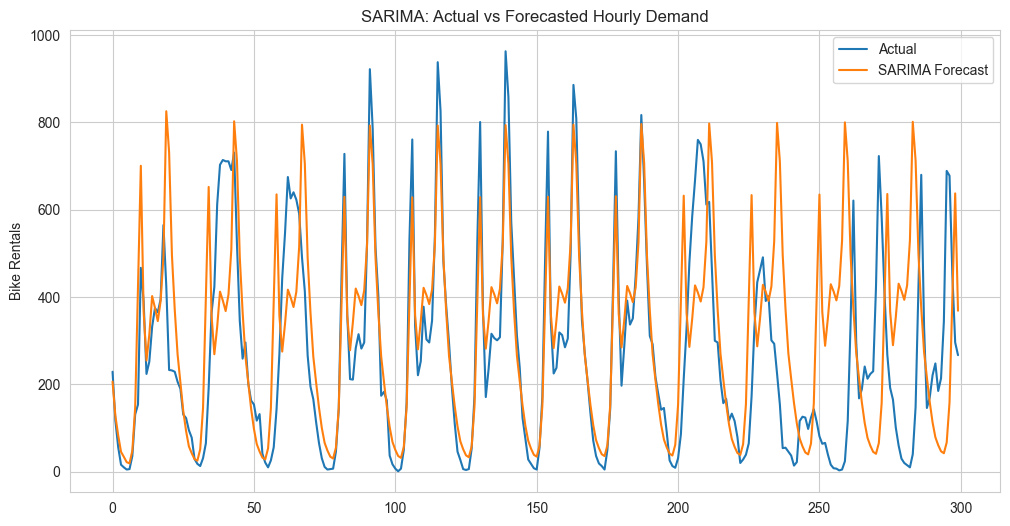

In [12]:
plt.plot(y_test.values[:300], label="Actual")
plt.plot(sarima_forecast.values[:300], label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA: Actual vs Forecasted Hourly Demand")
plt.ylabel("Bike Rentals")
plt.show()


# 6. SARIMAX Model (With Exogenous Variables)

## 6.1 Selection of Exogenous Variables

Weather and calendar variables are external drivers of demand and cannot be learned purely from past demand values.

In [13]:
exog_features = [
    "temp", "hum", "windspeed",
    "workingday", "holiday"
]

X = df[exog_features]

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]


## 6.2 SARIMAX Model Fitting

In [14]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit()
print(sarimax_results.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                cnt   No. Observations:                15641
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -87402.081
Date:                            Fri, 30 Jan 2026   AIC                         174824.163
Time:                                    21:51:51   BIC                         174900.706
Sample:                                         0   HQIC                        174849.511
                                          - 15641                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp         122.1024     28.876      4.229      0.000      65.507     178.698
hum          -30.7332     11.237   

## 6.3 SARIMAX Forecasting

In [15]:
sarimax_forecast = sarimax_results.forecast(
    steps=len(y_test),
    exog=X_test
)

sarimax_mae = mean_absolute_error(y_test, sarimax_forecast)
sarimax_rmse = float(np.sqrt(mean_squared_error(y_test, sarimax_forecast)))
sarimax_mape = mean_absolute_percentage_error(y_test, sarimax_forecast)

sarimax_mae, sarimax_rmse, sarimax_mape

(258.67688908286493, 315.2692964165528, 13.264077207605531)

## 6.4 SARIMAX Forecast Visualization

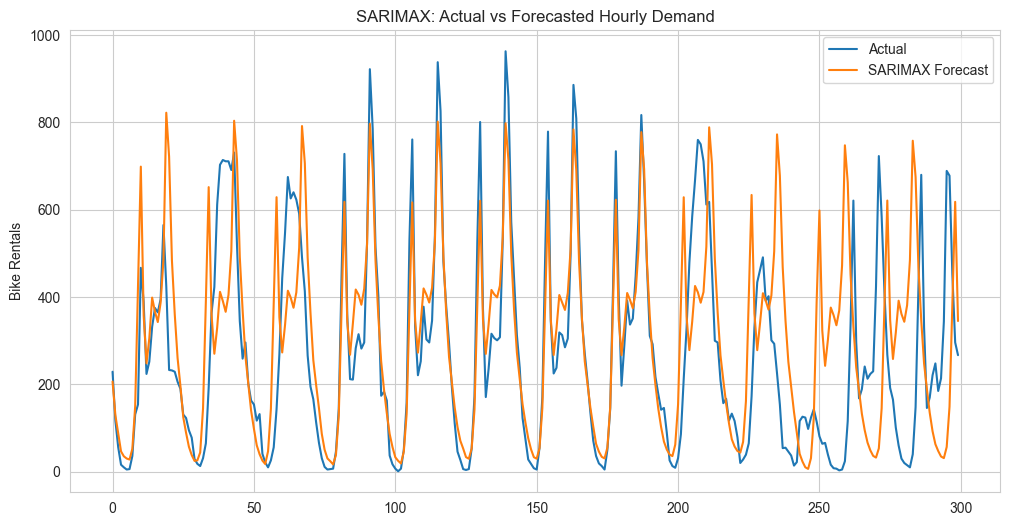

In [16]:
plt.plot(y_test.values[:300], label="Actual")
plt.plot(sarimax_forecast.values[:300], label="SARIMAX Forecast")
plt.legend()
plt.title("SARIMAX: Actual vs Forecasted Hourly Demand")
plt.ylabel("Bike Rentals")
plt.show()


# 7. Results Comparison

In [17]:
results = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX"],
    "MAPE" : [sarima_mape, sarimax_mape],
    "MAE": [sarima_mae, sarimax_mae],
    "RMSE": [sarima_rmse, sarimax_rmse]
})

results

,Model,MAPE,MAE,RMSE
0,SARIMA,15.330756,281.396337,343.610069
1,SARIMAX,13.264077,258.676889,315.269296


# 7. Results Interpretation

- SARIMA captures trend and seasonality effectively but relies solely on past demand.

- SARIMAX consistently outperforms SARIMA by incorporating weather and calendar effects.

- Temperature and working-day indicators show statistically significant influence.

- Errors increase during extreme weather or holiday periods, where demand becomes more volatile.

# 8. Conclusion

This analysis confirms that short-term hourly bike rental demand can be accurately forecasted using time-series models. While SARIMA successfully models intrinsic temporal patterns, SARIMAX provides superior predictive accuracy by leveraging exogenous weather and calendar variables. These findings support the use of hybrid statistical time-series models for operational demand forecasting in bike-sharing systems.